# FA2 - GridSearchCV for Random Forest

**Dataset:** Kaggle Wine Quality (Red Wine)

This is the separate notebook for Part 2. The same dataset is used here.


## 1. Import Libraries


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib


## 2. Load Dataset


In [2]:

df = pd.read_csv("winequality-red.csv")

print(df.head())
print("\nShape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

## 3. Simple EDA


       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

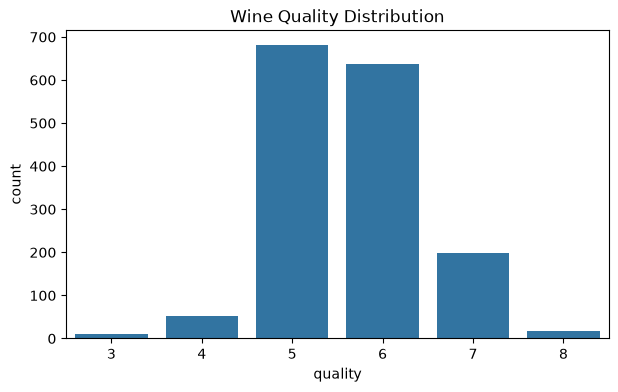

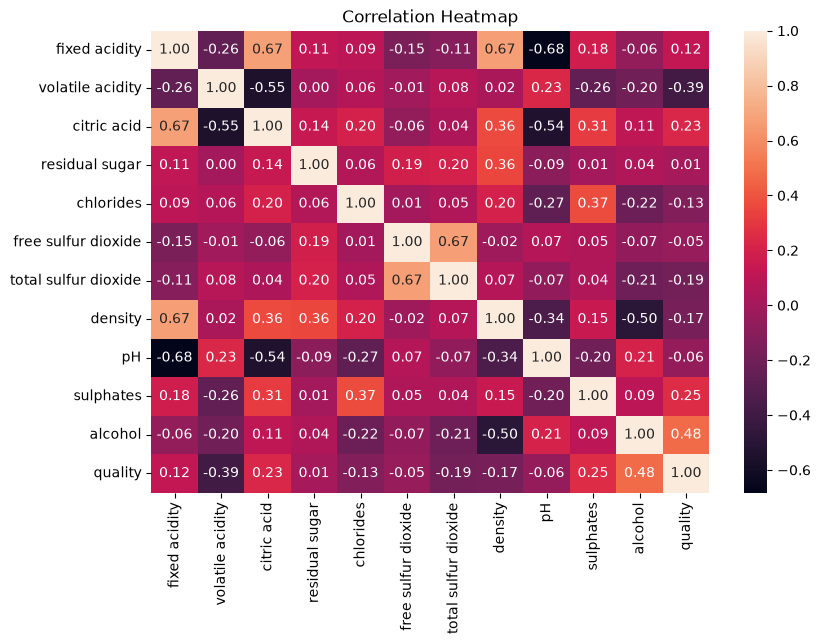

In [3]:

print(df.describe())

plt.figure(figsize=(7,4))
sns.countplot(x="quality", data=df)
plt.title("Wine Quality Distribution")
plt.show()

plt.figure(figsize=(9,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## 4. Prepare Data


In [4]:

X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (1279, 11)
Testing data: (320, 11)


## 5. Apply GridSearchCV


In [5]:

model = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross-Validation Score:")
print(grid.best_score_)


Best Parameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

Best Cross-Validation Score:
0.6809895833333333


## 6. Evaluate Tuned Random Forest


Test Accuracy: 0.675

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.63      0.73      0.68       128
           7       0.77      0.50      0.61        40
           8       0.00      0.00      0.00         3

    accuracy                           0.68       320
   macro avg       0.35      0.33      0.34       320
weighted avg       0.65      0.68      0.66       320


Confusion Matrix:
[[  0   0   1   1   0   0]
 [  0   0   8   3   0   0]
 [  0   0 103  32   1   0]
 [  0   0  31  93   4   0]
 [  0   0   3  16  20   1]
 [  0   0   0   2   1   0]]


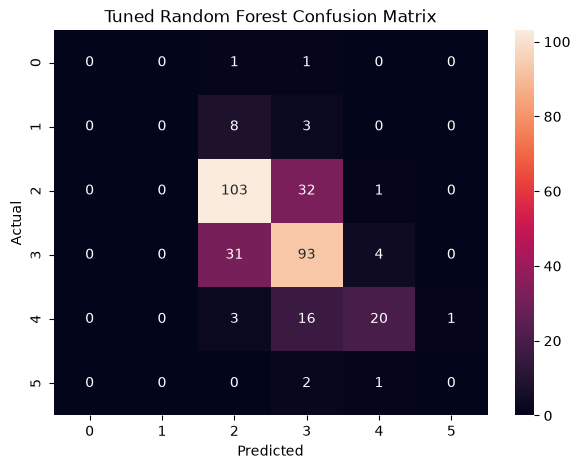

In [6]:

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 7. Save Model for Streamlit


In [7]:

joblib.dump(best_model, "best_wine_model.pkl")
print("Saved as best_wine_model.pkl")


Saved as best_wine_model.pkl


## 8. Conclusion

GridSearchCV used 5-fold cross-validation to test different Random Forest parameter combinations. The best parameters and cross-validation score are displayed above. The tuned model is saved for the Streamlit application.
